# CLASSIFICATION

In [20]:
import scanpy as sc

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score

In [22]:
import anndata as ad
import h5py
def read_h5ad(path: str, read_uns: bool = False):
    with h5py.File(path, 'r') as f:
        adata = ad.AnnData(
#             X=ad._io.h5ad.read_elem(f['X']) if 'X' in f else None,           
            obs=ad._io.h5ad.read_elem(f['obs']) if 'obs' in f else None,
            var=ad._io.h5ad.read_elem(f['var']) if 'var' in f else None,
            obsm=ad._io.h5ad.read_elem(f['obsm']) if 'obsm' in f else None,
            obsp=ad._io.h5ad.read_elem(f['obsp']) if 'obsp' in f else None,
            varm=ad._io.h5ad.read_elem(f['varm']) if 'varm' in f else None,
            varp=ad._io.h5ad.read_elem(f['varp']) if 'varp' in f else None,
            uns=ad._io.h5ad.read_elem(f['uns']) if read_uns and 'uns' in f else None,
        )
    return adata


In [23]:
import pickle
def open_from_pickle(sample_i):
    with open(sample_i,"rb") as handle:
        bar_m = pickle.load(handle)
    return bar_m

## First tests

### Nicheformer

In [27]:
adata2 = read_h5ad("/lustre/scratch127/cellgen/cellgeni/bc8/vqniche/analysis/benchmarking/kidney-task/nicheformer_embedded.h5ad")

/software/cellgen/team278/bc8/envs/scvi2/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [28]:
adata2

AnnData object with n_obs × n_vars = 260193 × 20310
    obs: 'soma_joinid', 'is_primary_data', 'dataset_id', 'donor_id', 'assay', 'cell_type', 'development_stage', 'disease', 'tissue', 'tissue_general', 'specie', 'technology', 'dataset', 'x', 'y', 'assay_ontology_term_id', 'sex_ontology_term_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'condition_id', 'tissue_type', 'library_key', 'organism', 'sex', 'niche', 'region', 'nicheformer_split', 'author_cell_type', 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'grade', 'clinical_risk', 'patien

In [18]:
adata2.obsm['X_niche_embeddings']

array([[-0.7803476 , -0.19732419, -0.17131908, ..., -0.12953748,
         0.00803273,  0.38915557],
       [-0.6219397 , -0.09900327, -0.3112083 , ..., -0.15418145,
        -0.2658894 ,  0.3619018 ],
       [-0.5941627 , -0.22091556, -0.10039305, ..., -0.20287806,
        -0.13825634,  0.32054907],
       ...,
       [-0.5326159 , -0.19023198, -0.25089127, ..., -0.16153413,
        -0.06732919,  0.3636736 ],
       [-0.5190636 , -0.09533048, -0.12894674, ..., -0.16529965,
        -0.00555649,  0.29535544],
       [-0.608384  ,  0.06674567, -0.1566316 , ..., -0.20121731,
         0.12073254,  0.29453444]], dtype=float32)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(adata2.obsm['X_niche_embeddings'], one_hot_array, test_size=0.20, random_state=42)

In [61]:
clf = RandomForestClassifier(max_depth=2, random_state=0)

In [62]:
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, random_state=0)

In [64]:
y_pred = clf.predict(X_test)

In [65]:
accuracy_score(y_test, y_pred)

0.7935586771459867

### Nichecompass

In [66]:
adata2 = read_h5ad("/lustre/scratch127/cellgen/cellgeni/bc8/vqniche/artifacts/sample_integration/12092025_150402/model/adata.h5ad")

/software/cellgen/team278/bc8/envs/scvi2/lib/python3.11/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [67]:
adata2

AnnData object with n_obs × n_vars = 260193 × 4949
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'grade', 'clinical_risk', 'patient', 'n_genes', 'original_cell_id'
    obsm: 'nichecompass_latent', 'spatial'
    varm: 'nichecompass_gp_sources', 'nichecompass_gp_sources_categories', 'nichecompass_gp_targets', 'nichecompass_gp_targets_categories'
    obsp: 'spatial_connectivities'

In [68]:
adata2.obsm['nichecompass_latent']

array([[  0.25216278,   2.69785786,   1.48398256, ...,   1.45680249,
          3.97215343,   0.06872443],
       [  0.46120217,   2.71038198,   0.80083984, ...,   1.43489742,
          0.9770655 ,   4.17417669],
       [  0.64733124,   3.38892436,   1.13439167, ...,   0.84449959,
          4.09103489,   2.94175005],
       ...,
       [ -2.25267863,  -1.32384503,  -3.07854605, ..., -14.16650963,
         -3.01689601,   6.06670094],
       [ -0.16265857,  -5.68845272,  -8.25894547, ...,  -0.2536552 ,
         -4.65596342,  -4.56228113],
       [  1.51781631,  -6.55657816,   2.05779243, ...,  -2.11886263,
         -9.9195776 ,   0.14656819]])

In [69]:
X_train, X_test, y_train, y_test = train_test_split(adata2.obsm['nichecompass_latent'], one_hot_array, test_size=0.20, random_state=42)

In [74]:
clf = RandomForestClassifier(max_depth=2, random_state=0)

In [75]:
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, random_state=0)

In [76]:
y_pred = clf.predict(X_test)

In [78]:
accuracy_score(y_test, y_pred)

0.970944868271873

### SQUINT

In [5]:
import pickle
def open_from_pickle(sample_i):
    with open(sample_i,"rb") as handle:
        bar_m = pickle.load(handle)
    return bar_m

In [6]:
# adata2 = open_from_pickle("/nfs/team361/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250910_145515-w2weep9e/results/epoch=0-train_pearson_1hop_nbr=0.91/predict_adata.pkl")
adata2 = open_from_pickle("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_210610-18vudyiz/results/epoch=0-train_pearson_1hop_nbr=0.92/predict_adata.pkl")

In [7]:
adata2

AnnData object with n_obs × n_vars = 260193 × 1000
    obs: 'clinical_risk', 'grade', 'adata_batch_ids'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'

In [9]:
adata2.obs['grade']

0         2
1         2
2         2
3         2
4         2
         ..
260188    4
260189    4
260190    4
260191    4
260192    4
Name: grade, Length: 260193, dtype: category
Categories (2, object): ['2', '4']

In [68]:
adata2.obsm['nichecompass_latent']

array([[  0.25216278,   2.69785786,   1.48398256, ...,   1.45680249,
          3.97215343,   0.06872443],
       [  0.46120217,   2.71038198,   0.80083984, ...,   1.43489742,
          0.9770655 ,   4.17417669],
       [  0.64733124,   3.38892436,   1.13439167, ...,   0.84449959,
          4.09103489,   2.94175005],
       ...,
       [ -2.25267863,  -1.32384503,  -3.07854605, ..., -14.16650963,
         -3.01689601,   6.06670094],
       [ -0.16265857,  -5.68845272,  -8.25894547, ...,  -0.2536552 ,
         -4.65596342,  -4.56228113],
       [  1.51781631,  -6.55657816,   2.05779243, ...,  -2.11886263,
         -9.9195776 ,   0.14656819]])

In [ ]:
encoder = OneHotEncoder()
encoder.fit(adata2.obs['grade'])
one_hot_array = encoder.transform(adata2.obs['grade']).toarray()


In [8]:
X_train, X_test, y_train, y_test = train_test_split(adata2.obsm['H_quantized'], one_hot_array, test_size=0.20, random_state=42)

NameError: name 'one_hot_array' is not defined

In [15]:
clf = RandomForestClassifier(max_depth=2, random_state=0)

In [16]:
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, random_state=0)

In [17]:
y_pred = clf.predict(X_test)

In [18]:
accuracy_score(y_test, y_pred)

0.8874690136243971

## Tests with function

In [2]:
from typing import Optional
import h5py
import anndata as ad
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score


def read_h5ad(path: str, read_uns: bool = False) -> ad.AnnData:
    """
    Read selected components of an .h5ad file using h5py and return an AnnData object.

    Parameters
    ----------
    path : str
        Path to the .h5ad file.
    read_uns : bool, optional (default: False)
        Whether to load the 'uns' field (can be large).

    Returns
    -------
    AnnData
        The AnnData object containing obs, var, obsm, obsp, varm, varp, and optionally uns.
    """
    with h5py.File(path, "r") as f:
        adata = ad.AnnData(
            # Uncomment if you want the main matrix
            # X=ad._io.h5ad.read_elem(f['X']) if 'X' in f else None,
            obs=ad._io.h5ad.read_elem(f["obs"]) if "obs" in f else None,
            var=ad._io.h5ad.read_elem(f["var"]) if "var" in f else None,
            obsm=ad._io.h5ad.read_elem(f["obsm"]) if "obsm" in f else None,
            obsp=ad._io.h5ad.read_elem(f["obsp"]) if "obsp" in f else None,
            varm=ad._io.h5ad.read_elem(f["varm"]) if "varm" in f else None,
            varp=ad._io.h5ad.read_elem(f["varp"]) if "varp" in f else None,
            uns=ad._io.h5ad.read_elem(f["uns"]) if read_uns and "uns" in f else None,
        )
    return adata

import pickle
def open_from_pickle(sample_i):
    with open(sample_i,"rb") as handle:
        bar_m = pickle.load(handle)
    return bar_m


def test_classification(adata_path, target_column, feature_key, test_size=0.20, max_depth=2, random_state=0):
    print("Reading adata...")
    if adata_path.endswith('h5ad'):
        adata = read_h5ad(adata_path)
    elif adata_path.endswith('pkl'):
        adata = open_from_pickle(adata_path) 

    if target_column not in adata.obs.columns:
        raise KeyError(f"Target column '{target_column}' not found in adata.obs.")
        
    print(f"Encoding target column '{target_column}' with one-hot encoding...")
    enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    y = enc.fit_transform(adata.obs[[target_column]])

    if type(feature_key) == str:
        if feature_key not in adata.obsm_keys():
            raise KeyError(f"Feature key '{feature_key}' not found in adata.obsm.")
        else:
            print(f"Using features from adata.obsm['{feature_key}']...")
            X = adata.obsm[feature_key]
    elif type(feature_key) == torch.Tensor:
        print(f"Using features from the tensor '{feature_key}']...")
        X = feature_key    
    
    print("Splitting train and test...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    print("Training random forest classifier...")
    clf = RandomForestClassifier(max_depth=max_depth, random_state=random_state, n_jobs=-1)
    clf.fit(X_train, y_train)
    
    print("Predicting using classifier...")
    y_pred = clf.predict(X_test)
    
    score = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {score:.4f}")
    
    return score



from typing import Literal, Optional
import torch

def aggregate_1hop_neighbor_features(
        X: torch.Tensor,
        edge_index: torch.Tensor,
        return_mean: bool = False,
        batch_size: Optional[int] = None,
    ) -> torch.Tensor:
    """
    Compute the sum of the attribute vectors of the 1-hop neighbors of each node and return their mean if return_mean is True, otherwise return the sum.

    Parameters
    ----------
    - X: torch.Tensor
        The attribute vectors of the nodes.
        Dimensions: (num_nodes, num_features)
    - edge_index: torch.Tensor
        The edge index of the graph.
        Dimensions: (2, num_edges)
    - return_mean: bool
        Whether to return the mean or the sum of the neighbor features.
    - batch_size: Optional[int]
        The number of source nodes of the batch. If provided, the function will return the mean or sum of the neighbor features for the source nodes only (i.e. the first `batch_size` rows of `X`). If not provided, the function will return the mean or sum of the neighbor features for all nodes.

    Returns
    -------
    - X_nbr: torch.Tensor
        The mean or sum of the attribute vectors of the 1-hop neighbors of each node.
        Dimensions: (num_nodes, num_features) if batch_size is not provided, otherwise (batch_size, num_features)

    Notes
    -----
    - This assumes that all nodes have a self-loop.
    """    
    # edge_index is assumed to have self-loops
    row, col = edge_index  # source -> target

    if batch_size is not None:
        assert batch_size <= X.size(0), "`batch_size` must be <= number of nodes"
        mask = col < batch_size
        row, col = row[mask], col[mask]
        X_nbr = torch.zeros((batch_size, X.size(1)), device=X.device, dtype=X.dtype)
    else:
        X_nbr = torch.zeros_like(X, device=X.device, dtype=X.dtype)

    # aggregate sums
    if row.numel() > 0:
        X_nbr.index_add_(0, col, X[row])

    if return_mean:
        deg = torch.zeros(X_nbr.size(0), dtype=X.dtype, device=X.device)
        if col.numel() > 0:
            deg.index_add_(0, col, torch.ones_like(col, dtype=X.dtype))
        X_nbr = X_nbr / deg.clamp(min=1).unsqueeze(1)

    return X_nbr

In [3]:
adata = open_from_pickle("/nfs/team361/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250910_145515-w2weep9e/results/epoch=0-train_pearson_1hop_nbr=0.91/predict_adata.pkl")

In [7]:
adata

AnnData object with n_obs × n_vars = 260193 × 1000
    obs: 'grade', 'clinical_risk', 'adata_batch_ids'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'

**Works great!!**

In [4]:
# Nicheformer
adata_path = "/lustre/scratch127/cellgen/cellgeni/bc8/vqniche/analysis/benchmarking/kidney-task/nicheformer_embedded.h5ad"
feature_key = 'X_niche_embeddings'
target_column = 'clinical_risk'

accuracy_scores_nicheformer = []
for i in [0]:
    print(f'random state: {i}')
    accuracy_scores_nicheformer.append(test_classification(adata_path, target_column, feature_key, test_size=0.8, max_depth=10, random_state=i))
    print(f'------')

random state: 0
Reading adata...


/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Encoding target column 'clinical_risk' with one-hot encoding...
Using features from adata.obsm['X_niche_embeddings']...
Splitting train and test...
Training random forest classifier...
Predicting using classifier...
Accuracy: 0.8586
------


In [5]:
# Nichecompass
adata_path = "/lustre/scratch127/cellgen/cellgeni/bc8/vqniche/artifacts/sample_integration/12092025_150402/model/adata.h5ad"
feature_key = 'nichecompass_latent'
target_column = 'clinical_risk'

accuracy_scores_nichecompass = []
for i in [0]:
    print(f'random state: {i}')
    accuracy_scores_nichecompass.append(test_classification(adata_path, target_column, feature_key, test_size=0.8, max_depth=10, random_state=i))
    print(f'------')

random state: 0
Reading adata...


/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Encoding target column 'clinical_risk' with one-hot encoding...
Using features from adata.obsm['nichecompass_latent']...
Splitting train and test...
Training random forest classifier...
Predicting using classifier...
Accuracy: 0.9997
------


In [ ]:
# For classification scores:
# VQNiche: H_quantized
# VQniche (1-hop): aggregate function (H_quantised, return)
# H_latent
# VQniche (1-hop): aggregate function (H_latent, return)

In [6]:
# SQUINT (VQNiche)
# adata_path = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250910_145515-w2weep9e/results/epoch=0-train_pearson_1hop_nbr=0.91/predict_adata.pkl"
adata_path = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_210610-18vudyiz/results/epoch=0-train_pearson_1hop_nbr=0.92/predict_adata.pkl"
# adata_path = "/nfs/team361/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_220115-ldg9jjpv/results/epoch=9-train_pearson_1hop_nbr=0.93/predict_adata.pkl"
feature_key = 'H_quantized'
target_column = 'clinical_risk'

accuracy_scores_squint0 = []
for i in [0]:
    print(f'random state: {i}')
    accuracy_scores_squint0.append(test_classification(adata_path, target_column, feature_key, test_size=0.8, max_depth=10, random_state=i))
    print(f'------')

random state: 0
Reading adata...
Encoding target column 'clinical_risk' with one-hot encoding...
Using features from adata.obsm['H_quantized']...
Splitting train and test...
Training random forest classifier...
Predicting using classifier...
Accuracy: 0.9689
------


In [20]:
# VQNiche (1-hop)
# adata_path = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250910_145515-w2weep9e/results/epoch=0-train_pearson_1hop_nbr=0.91/predict_adata.pkl"
adata_path = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_210610-18vudyiz/results/epoch=0-train_pearson_1hop_nbr=0.92/predict_adata.pkl"
# adata_path = "/nfs/team361/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_220115-ldg9jjpv/results/epoch=9-train_pearson_1hop_nbr=0.93/predict_adata.pkl"
adata = open_from_pickle(adata_path)
feature_key = 'H_quantized'
target_column = 'clinical_risk'

vqn_1hop = aggregate_1hop_neighbor_features(torch.from_numpy(adata.obsm[feature_key]), adata.uns['edge_index'], return_mean=True)
feature_key = vqn_1hop


accuracy_scores_squint1 = []
for i in [0]:
    print(f'random state: {i}')
    accuracy_scores_squint1.append(test_classification(adata_path, target_column, feature_key, test_size=0.8, max_depth=10, random_state=i))
    print(f'------')

random state: 0
Reading adata...
Encoding target column 'clinical_risk' with one-hot encoding...
Using features from the tensor 'tensor([[-0.0649,  0.0174, -0.0650,  ...,  0.0177, -0.0554,  0.0040],
        [-0.0864,  0.0125, -0.0634,  ...,  0.0149, -0.0222,  0.0100],
        [-0.0792,  0.0141, -0.0586,  ...,  0.0180, -0.0356,  0.0076],
        ...,
        [-0.0279,  0.0816,  0.0280,  ..., -0.0197,  0.0096, -0.0170],
        [-0.0478,  0.0496, -0.0263,  ...,  0.0015,  0.0014,  0.0628],
        [ 0.0444, -0.0455, -0.0320,  ..., -0.1015,  0.1019,  0.0992]])']...
Splitting train and test...
Training random forest classifier...
Predicting using classifier...
Accuracy: 0.9800
------


In [8]:
# VQNiche (H_latent)
# adata_path = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250910_145515-w2weep9e/results/epoch=0-train_pearson_1hop_nbr=0.91/predict_adata.pkl"
adata_path = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_210610-18vudyiz/results/epoch=0-train_pearson_1hop_nbr=0.92/predict_adata.pkl"
# adata_path = "/nfs/team361/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_220115-ldg9jjpv/results/epoch=9-train_pearson_1hop_nbr=0.93/predict_adata.pkl"
feature_key = 'H_latent'
target_column = 'clinical_risk'

accuracy_scores_squint2 = []
for i in [0]:
    print(f'random state: {i}')
    accuracy_scores_squint2.append(test_classification(adata_path, target_column, feature_key, test_size=0.8, max_depth=10, random_state=i))
    print(f'------')

random state: 0
Reading adata...
Encoding target column 'clinical_risk' with one-hot encoding...
Using features from adata.obsm['H_latent']...
Splitting train and test...
Training random forest classifier...
Predicting using classifier...
Accuracy: 0.9579
------


In [9]:
# VQNiche (H_latent, 1-hop)
# adata_path = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250910_145515-w2weep9e/results/epoch=0-train_pearson_1hop_nbr=0.91/predict_adata.pkl"
adata_path = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_210610-18vudyiz/results/epoch=0-train_pearson_1hop_nbr=0.92/predict_adata.pkl"
# adata_path = "/nfs/team361/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_220115-ldg9jjpv/results/epoch=9-train_pearson_1hop_nbr=0.93/predict_adata.pkl"
feature_key = 'H_latent'
target_column = 'clinical_risk'

vqn_1hop = aggregate_1hop_neighbor_features(torch.from_numpy(adata.obsm[feature_key]), adata.uns['edge_index'], return_mean=True)
feature_key = vqn_1hop

accuracy_scores_squint3 = []
for i in [0]:
    print(f'random state: {i}')
    accuracy_scores_squint3.append(test_classification(adata_path, target_column, feature_key, test_size=0.8, max_depth=10, random_state=i))
    print(f'------')

random state: 0
Reading adata...
Encoding target column 'clinical_risk' with one-hot encoding...
Using features from the tensor 'tensor([[-0.2022,  0.0470, -0.1011,  ...,  0.0697, -0.2491, -0.0654],
        [-0.2248, -0.0096, -0.1887,  ...,  0.1164, -0.1884,  0.0393],
        [-0.2327, -0.0181, -0.1508,  ...,  0.1264, -0.2275, -0.0441],
        ...,
        [-0.4276,  0.8769,  0.2716,  ..., -0.0798,  0.6308, -0.3005],
        [-0.2956,  0.0918, -0.0954,  ...,  0.4253,  1.2338,  0.4422],
        [ 0.1711, -0.0448, -0.0079,  ..., -0.4950,  0.1818, -0.0347]])']...
Splitting train and test...
Training random forest classifier...
Predicting using classifier...
Accuracy: 0.9726
------


In [11]:
import pandas as pd
accuracy_scores_all = pd.DataFrame([np.mean(accuracy_scores_nicheformer), np.mean(accuracy_scores_nichecompass), np.mean(accuracy_scores_squint1)]) 

In [12]:
accuracy_scores_all.index = ['nicheformer', 'nichecompass', 'vqniche']

In [13]:
accuracy_scores_all

,0
nicheformer,0.858562
nichecompass,0.999731
vqniche,0.980025


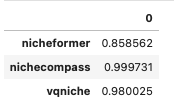# SCORE

In [1]:
import pandas as pd
from torch_geometric.utils import k_hop_subgraph
from tqdm import tqdm
import scanpy as sc
import anndata as ad
import numpy as np
from pathlib import Path

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
import anndata as ad
import h5py
def read_h5ad(path: str, read_uns: bool = False):
    with h5py.File(path, 'r') as f:
        adata = ad.AnnData(
#             X=ad._io.h5ad.read_elem(f['X']) if 'X' in f else None,           
            obs=ad._io.h5ad.read_elem(f['obs']) if 'obs' in f else None,
            var=ad._io.h5ad.read_elem(f['var']) if 'var' in f else None,
            obsm=ad._io.h5ad.read_elem(f['obsm']) if 'obsm' in f else None,
            obsp=ad._io.h5ad.read_elem(f['obsp']) if 'obsp' in f else None,
            varm=ad._io.h5ad.read_elem(f['varm']) if 'varm' in f else None,
            varp=ad._io.h5ad.read_elem(f['varp']) if 'varp' in f else None,
            uns=ad._io.h5ad.read_elem(f['uns']) if read_uns and 'uns' in f else None,
        )
    return adata


In [2]:
import pickle
def open_from_pickle(sample_i):
    with open(sample_i,"rb") as handle:
        bar_m = pickle.load(handle)
    return bar_m

In [3]:
adata_path = "/nfs/team361/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_220115-ldg9jjpv/results/epoch=9-train_pearson_1hop_nbr=0.93/predict_adata.pkl"
adata = open_from_pickle(adata_path)
adata

AnnData object with n_obs × n_vars = 260193 × 1000
    obs: 'grade', 'clinical_risk', 'adata_batch_ids'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'

In [21]:
adata.obs['SQUINT_token'] = adata.uns['Indices'].numpy()
adata

AnnData object with n_obs × n_vars = 260193 × 1000
    obs: 'grade', 'clinical_risk', 'adata_batch_ids', 'top5_1nbr_code-activation-score', 'SQUINT_token'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads', 'topk_indices_from_highrisk'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'

In [22]:
adata.obs['top5_1nbr_code-activation-score']

0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
            ...   
260188    0.090909
260189    0.166667
260190    0.100000
260191    0.100000
260192    0.000000
Name: top5_1nbr_code-activation-score, Length: 260193, dtype: float32

In [23]:
adata.obs['SQUINT_token']

0          666
1          515
2          685
3          882
4          836
          ... 
260188    1176
260189     804
260190    1177
260191     207
260192     187
Name: SQUINT_token, Length: 260193, dtype: int64

In [8]:
orig_adata_list = []
dir_path = Path("/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p")
for fname in list(dir_path.glob('**/*.h5ad')):
    print(fname)
    orig_adata_list.append(sc.read_h5ad(fname))
orig_adata = ad.concat(orig_adata_list)
orig_adata

/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p/adata_batch1.h5ad
/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p/adata_batch3.h5ad
/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p/adata_batch0.h5ad
/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p/adata_batch2.h5ad
/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p/adata_batch4.h5ad


/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 260193 × 4949
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'grade', 'clinical_risk', 'patient', 'n_genes', 'original_cell_id'
    obsm: 'spatial'

In [10]:
orig_adata.obsm['spatial'].shape

(260193, 2)

In [11]:
adata.obsm['spatial'].shape

(260193, 2)

In [33]:
mapping = {}

updated_orig_a = []

for orig_a in orig_adata_list:
    for i in adata.obs['adata_batch_ids'].unique():
        pred_a = adata[adata.obs['adata_batch_ids']==i]
        if orig_a.shape[0] == pred_a.shape[0]:
            mapping[orig_a.obs['batch'].unique().tolist()[0]] = i
            print(np.sum(pred_a.obsm['spatial'] == orig_a.obsm['spatial'])/2)
            print(np.sum(pred_a.obsm['spatial'] == orig_a.obsm['spatial'])/2 == orig_a.shape[0])
            orig_a.obs['top5_1nbr_code-activation-score'] = np.array(pred_a.obs['top5_1nbr_code-activation-score']).astype(np.float32)
            orig_a.obs['SQUINT_token'] = np.array(pred_a.obs['SQUINT_token']).astype(np.int32)
            print(orig_a.obs['top5_1nbr_code-activation-score'].mean())
            # print(orig_a.obs['SQUINT_token'])
            print(pred_a)
            print(orig_a)
            updated_orig_a.append(orig_a)
            print("---")
            break
print(mapping)

71118.0
True
0.0025096503
View of AnnData object with n_obs × n_vars = 71118 × 1000
    obs: 'grade', 'clinical_risk', 'adata_batch_ids', 'top5_1nbr_code-activation-score', 'SQUINT_token'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads', 'topk_indices_from_highrisk'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'
AnnData object with n_obs × n_vars = 71118 × 4949
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'grade', 'clinical_risk', 'patient', 'n_genes', 'original_cell_id', 'top5_1nb

In [34]:
updated_orig_a = ad.concat(updated_orig_a)

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [39]:
updated_orig_a

AnnData object with n_obs × n_vars = 260193 × 4949
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'grade', 'clinical_risk', 'patient', 'n_genes', 'original_cell_id', 'top5_1nbr_code-activation-score', 'SQUINT_token'
    obsm: 'spatial'

In [37]:
updated_orig_a.shape

(260193, 4949)

In [35]:
updated_orig_a.obs['top5_1nbr_code-activation-score']

0        0.000000
1        0.000000
2        0.000000
3        0.000000
4        0.000000
           ...   
30489    0.090909
30547    0.166667
30551    0.100000
30553    0.100000
30583    0.000000
Name: top5_1nbr_code-activation-score, Length: 260193, dtype: float32

In [38]:
updated_orig_a.write("/nfs/team361/am84/VQNiche/xhk1020-CV1-CV2-5b_1p_code-activation-score.h5ad")

In [20]:
adata[adata.obs['adata_batch_ids']==0]

View of AnnData object with n_obs × n_vars = 58432 × 1000
    obs: 'grade', 'clinical_risk', 'adata_batch_ids'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'

In [23]:
adata.obs['adata_batch_ids'].unique()

array([0, 1, 2, 3, 4])

In [ ]:
# 1. Get Top5Codes
# 2. score[cell] = 0

# For tissue in tissues:
# 	- edge_index for this tissue
# 	- For cell in tissue:
# 		- edge_index_k_hop_cell = k_hop_subgraph(cell, num_hops=1, edge_index=edge_index) 
# 		- 0 -> [1, 2, 7, 10, 92]
# 		- N(cell) = [0, 1, 2, 7, 10, 92]
# 		- for nbr in N(cell):
# 			- if Indices[nbr] in Top5Codes
# 				- score[cell] += 1
# 		- score[cell] = score[cell] / len(N(cell))

# Plot the cells by xy coordinates and colored by score

In [24]:
import torch
torch.cuda.is_available()

True

In [28]:
device = torch.device('cuda')

In [25]:
clinical_risk = 'low'

count_indices = np.zeros(max(adata.uns['Indices'])+1, dtype=int)
ad_subset = adata[adata.obs['clinical_risk'] == clinical_risk]
for c in ad_subset.obs.index:
    count_indices[adata.uns['Indices'][int(c)]] += 1
    
top5codes = pd.Series(count_indices).value_counts().nlargest(5, keep='all').index.to_numpy()

In [ ]:
all_scores = np.zeros(adata.n_obs, dtype=int)

In [ ]:
ei = torch.as_tensor(adata.uns['edge_index'], dtype=torch.long, device=device)

for cell in tqdm(ad_subset.obs.index):
    node_idx = torch.tensor([int(cell)], dtype=torch.long, device=device)
    ncell = k_hop_subgraph(node_idx, num_hops=1, edge_index=ei)[0]
    score = 0
    for c in ncell:
        if adata.uns['Indices'][c] in top5codes:
            score += 1
    all_scores[int(cell)] = score / len(ncell)

  6%|▌         | 12706/206864 [00:22<05:20, 605.00it/s]

In [ ]:
# OLD VERSION
# all_scores = np.zeros(adata.n_obs, dtype=int)

# for cell in tqdm(ad_subset.obs.index):
#     ncell = k_hop_subgraph(torch.IntTensor([0]), num_hops=1, edge_index=adata.uns['edge_index'])[0]
#     score = 0
#     for c in ncell:
#         if adata.uns['Indices'][c] in top5codes:
#             score += 1
#     all_scores[int(cell)] = score / len(ncell)

In [26]:
clinical_risk = 'high'

count_indices = np.zeros(max(adata.uns['Indices'])+1, dtype=int)
ad_subset = adata[adata.obs['clinical_risk'] == clinical_risk]
for c in ad_subset.obs.index:
    count_indices[adata.uns['Indices'][int(c)]] += 1
    
top5codes = pd.Series(count_indices).value_counts().nlargest(5, keep='all').index.to_numpy()

In [29]:
all_scores = np.zeros(adata.n_obs, dtype=int)

ei = torch.as_tensor(adata.uns['edge_index'], dtype=torch.long, device=device)

for cell in tqdm(ad_subset.obs.index):
    node_idx = torch.tensor([int(cell)], dtype=torch.long, device=device)
    ncell = k_hop_subgraph(node_idx, num_hops=1, edge_index=ei)[0]
    score = 0
    for c in ncell:
        if adata.uns['Indices'][c] in top5codes:
            score += 1
    all_scores[int(cell)] = score / len(ncell)

100%|██████████| 53329/53329 [01:20<00:00, 660.70it/s]


In [36]:
top5codes

array([0, 1, 2, 3, 4])

In [54]:
top5indices = np.argsort(count_indices)[-5:][::-1]
top5indices

array([  37,  397, 2072,  147,   10])

In [57]:
ad_subset.uns['Indices'].shape

torch.Size([260193])

In [38]:
all_scores = np.zeros(adata.n_obs, dtype=int)

ei = torch.as_tensor(adata.uns['edge_index'], dtype=torch.long, device=device)

for cell in tqdm(adata.obs.index):
    node_idx = torch.tensor([int(cell)], dtype=torch.long, device=device)
    ncell = k_hop_subgraph(node_idx, num_hops=1, edge_index=ei)[0]
    ncells = list(ncells.cpu().numpy()) + [cell]
    score = 0
    for c in ncell:
        if adata.uns['Indices'][c] in top5indices:
            score += 1
    all_scores[int(cell)] = score / len(ncell)

100%|██████████| 260193/260193 [06:36<00:00, 655.63it/s]


In [43]:
torch.max(ei)

tensor(260192, device='cuda:0')

In [53]:
flag = 0
for cell in tqdm(range(adata.uns['Indices'].shape[0])):
    ncells = k_hop_subgraph([cell], num_hops=1, edge_index=ei)[0]
    ncells = list(ncells.cpu().numpy()) + [cell]
    for nc in ncells:
        if flag == 1:
            break
        if adata.uns['Indices'][nc] in top5indices:
            print(nc, adata.uns['Indices'][nc])
            flag = 1

 31%|███       | 81197/260193 [01:49<04:01, 742.70it/s]


KeyboardInterrupt: 

In [50]:
adata.uns['Indices'][0]

tensor(666)

In [4]:
import numpy as np
import torch
from torch_geometric.utils import to_undirected, coalesce, degree
from collections import Counter

def compute_topk_neighbor_score(adata, k: int, indices_key: str = "Indices", edge_index_key: str = "edge_index",
                                risk_col: str = "clinical_risk", high_label: str = "high",
                                out_col: str = "topk_nbr_score"):
    """
    Computes, for every cell, the fraction of its 1-hop neighbors (+ itself) whose `Indices`
    fall in the top-k most frequent `Indices` among high-risk cells.

    Assumptions
    -----------
    - `adata.uns[indices_key]` is a 1D array-like of length n_obs giving a per-cell code/index (int).
    - `adata.uns[edge_index_key]` is a 2 x E array-like (PyG COO) of edges (0-based node ids).
    - Graph is unweighted; self-loops will be added implicitly by counting 'self' in numerator/denominator.
    """
    n = adata.n_obs

    # --- 1) Top-k indices among high-risk cells ---
    mask_high = (adata.obs[risk_col].values == high_label)
    indices = np.asarray(adata.uns[indices_key]).reshape(-1)
    if indices.shape[0] != n:
        raise ValueError(f"`adata.uns['{indices_key}']` must have length n_obs ({n}), got {indices.shape[0]}.")

    # most common k indices within high-risk subset
    high_indices = indices[mask_high]
    if high_indices.size == 0:
        # No high-risk cells; define empty top-k (scores will be 0)
        topk_vals = []
    else:
        counts = Counter(high_indices.tolist())
        topk_vals = [idx for idx, _cnt in counts.most_common(k)]

    # boolean per node: is this node's index in the top-k set?
    is_topk = torch.from_numpy(np.isin(indices, np.array(topk_vals))).to(torch.float32)

    # --- 2) Build undirected graph & aggregate 1-hop neighbor values ---
    edge_index = np.asarray(adata.uns[edge_index_key])
    if edge_index.shape[0] != 2:
        raise ValueError(f"`adata.uns['{edge_index_key}']` must be shape (2, E). Got {edge_index.shape}.")

    edge_index = torch.as_tensor(edge_index, dtype=torch.long)
    # ensure valid shape and node ids
    if edge_index.numel() > 0:
        edge_index = to_undirected(edge_index, num_nodes=n)
        # coalesce to drop duplicates, keep it tidy
        edge_index, _ = coalesce(edge_index, None, n, n)
    else:
        # empty graph
        edge_index = torch.empty((2,0), dtype=torch.long)

    # sum of neighbor 'is_topk' for each node (exclude self here; will add below)
    if edge_index.numel() > 0:
        # aggregate values from source->target
        src, dst = edge_index[0], edge_index[1]
        # neighbor_sum[i] = sum_{j in N(i)} is_topk[j]
        neighbor_sum = torch.zeros(n, dtype=torch.float32)
        neighbor_sum.index_add_(0, dst, is_topk[src])

        # degree per node
        deg = degree(dst, num_nodes=n, dtype=torch.float32)
    else:
        neighbor_sum = torch.zeros(n, dtype=torch.float32)
        deg = torch.zeros(n, dtype=torch.float32)

    # include self in numerator and denominator
    num = neighbor_sum + is_topk  # add self
    den = deg + 1.0               # +1 for self

    score = (num / den).numpy()

    # write results back to AnnData
    adata.obs[out_col] = score
    adata.uns["topk_indices_from_highrisk"] = np.array(topk_vals, dtype=high_indices.dtype if high_indices.size else int)

    return adata  # returned for convenience

In [5]:
adata1 = compute_topk_neighbor_score(
    adata,
    k=5,
    indices_key="Indices",
    edge_index_key="edge_index",
    risk_col="clinical_risk",
    high_label="high",
    out_col="top5_1nbr_code-activation-score"
)
adata1

AnnData object with n_obs × n_vars = 260193 × 1000
    obs: 'grade', 'clinical_risk', 'adata_batch_ids', 'top5_1nbr_code-activation-score'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads', 'topk_indices_from_highrisk'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'

In [40]:
adata

AnnData object with n_obs × n_vars = 260193 × 1000
    obs: 'grade', 'clinical_risk', 'adata_batch_ids', 'top5_1nbr_code-activation-score'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads', 'topk_indices_from_highrisk'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'

(58432, 1000)

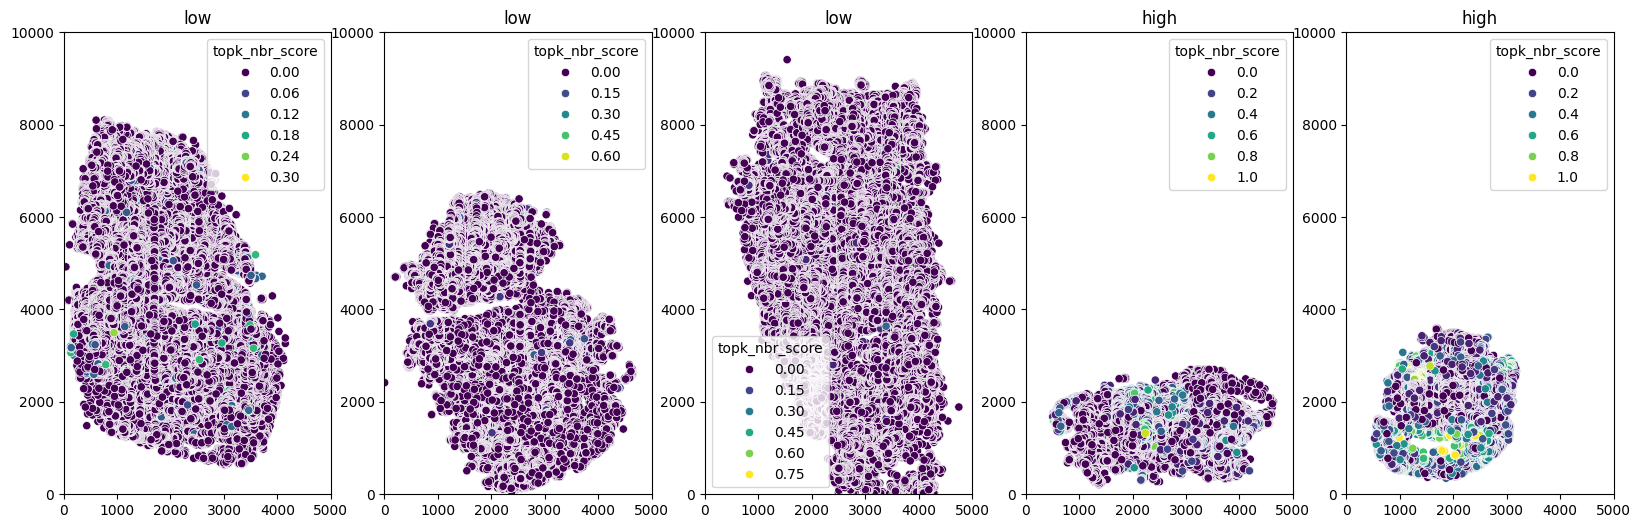

In [104]:
spatial_key = 'spatial'
label_key = "topk_nbr_score"
batches = list(adata1.obs['adata_batch_ids'].unique())
fig, axes = plt.subplots(1, len(batches), figsize=(4*len(batches), 6))

for i, ax in enumerate(axes):
    a0 = adata1[adata1.obs['adata_batch_ids'] == i]
    sns.scatterplot(        
        x=a0.obsm[spatial_key][:,0],
        y=a0.obsm[spatial_key][:,1],
        hue=a0.obs[label_key],
        ax=ax,
        palette="viridis"
        # palette=sns.cubehelix_palette(start=.5, rot=-.95, as_cmap=True)
    )
    ax.set_xlim(0, 5000)
    ax.set_ylim(0, 10000)
    ax.set_title(a0.obs['clinical_risk'].unique()[0])

plt.show()

In [93]:
def plot_spatial_score_by_batch_sns(
    adata,
    spatial_key: str = "spatial",
    label_key: str = "topk_nbr_score",
    batch_key: str = "adata_batch_ids",
    batches=None,                 # list/array of batch ids to include; default = all
    title: str = "Spatial distribution of score by batch",
    xlim=None,                    # set to -1 to autoscale per panel
    ylim=None,                    # set to -1 to autoscale per panel
    vmin=None,                    # color scale min; default = global min of label
    vmax=None,                    # color scale max; default = global max of label
    cmap: str = "vlag",
    point_size: float = 3.0,
    alpha: float = 0.9,
    col_wrap: int = 5,            # wrap after N columns
    height: float = 4.0,          # seaborn facet height (inches)
    aspect: float = 1.2,          # width = height * aspect
    tight: bool = True,
    show: bool = True,
):
    """
    Seaborn FacetGrid of `obsm[spatial_key]` colored by `obs[label_key]`
    for each level of `obs[batch_key]`. Produces a single shared colorbar.
    """
    # --- checks ---
    if spatial_key not in adata.obsm:
        raise KeyError(f"obsm['{spatial_key}'] not found.")
    if label_key not in adata.obs.columns:
        raise KeyError(f"obs['{label_key}'] not found.")
    if batch_key not in adata.obs.columns:
        raise KeyError(f"obs['{batch_key}'] not found.")

    XY = np.asarray(adata.obsm[spatial_key])
    if XY.ndim != 2 or XY.shape[1] < 2:
        raise ValueError(f"obsm['{spatial_key}'] must be an (n_obs, 2+) array.")

    labels = np.asarray(adata.obs[label_key])
    if labels.shape[0] != XY.shape[0]:
        raise ValueError("Label length does not match number of observations.")

    batches_all = np.asarray(adata.obs[batch_key])

    # build dataframe for seaborn
    df = pd.DataFrame({
        "x": XY[:, 0],
        "y": XY[:, 1],
        "score": labels,
        "batch": batches_all
    })

    if batches is not None:
        df = df[df["batch"].isin(batches)]

    if df.empty:
        raise ValueError("No data to plot after filtering batches.")

    # global limits unless user asked for per-panel autoscale (-1)
    if xlim is None:
        xlim_eff = (np.nanmin(df["x"]), np.nanmax(df["x"]))
    elif xlim == -1:
        xlim_eff = None
    else:
        xlim_eff = xlim

    if ylim is None:
        ylim_eff = (np.nanmin(df["y"]), np.nanmax(df["y"]))
    elif ylim == -1:
        ylim_eff = None
    else:
        ylim_eff = ylim

    # global color scale
    if vmin is None:
        vmin = float(np.nanmin(df["score"]))
    if vmax is None:
        vmax = float(np.nanmax(df["score"]))

    # seaborn facet
    g = sns.FacetGrid(
        df, col="batch", col_wrap=col_wrap,
        height=height, aspect=aspect, sharex=(xlim_eff is not None), sharey=(ylim_eff is not None),
        despine=True
    )

    # map dataframe with seaborn.scatterplot (continuous hue)
    # legend=False so we can add a single shared colorbar
    g.map_dataframe(
        sns.scatterplot,
        x="x", y="y",
        hue="score",
        palette=cmap,
        hue_norm=(vmin, vmax),
        s=point_size,
        edgecolor=None,
        linewidth=0,
        alpha=alpha,
        legend=False,
    )

    # per-axes formatting
    for ax in g.axes.flat:
        if ax is None:
            continue
        ax.set_aspect("equal", adjustable="box")
        if xlim_eff is not None:
            ax.set_xlim(xlim_eff)
        if ylim_eff is not None:
            ax.set_ylim(ylim_eff)
        ax.set_xlabel("X coordinate")
        ax.set_ylabel("Y coordinate")

    # titles
    g.set_titles(col_template="Batch {col_name}")

    # single shared colorbar
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize
    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
    sm.set_array([])  # needed for older mpl
    cbar = g.figure.colorbar(sm, ax=g.axes, fraction=0.02, pad=0.02)
    cbar.set_label(label_key)

    # overall title
    g.figure.suptitle(title, y=1.02)

    # tight layout
    if tight:
        try:
            g.tight_layout()
        except Exception:
            plt.tight_layout()
        # keep room for suptitle
        plt.subplots_adjust(top=0.9)

    if show:
        plt.show()

    return g.figure, g.axes

/tmp/ipykernel_1834429/1703228136.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


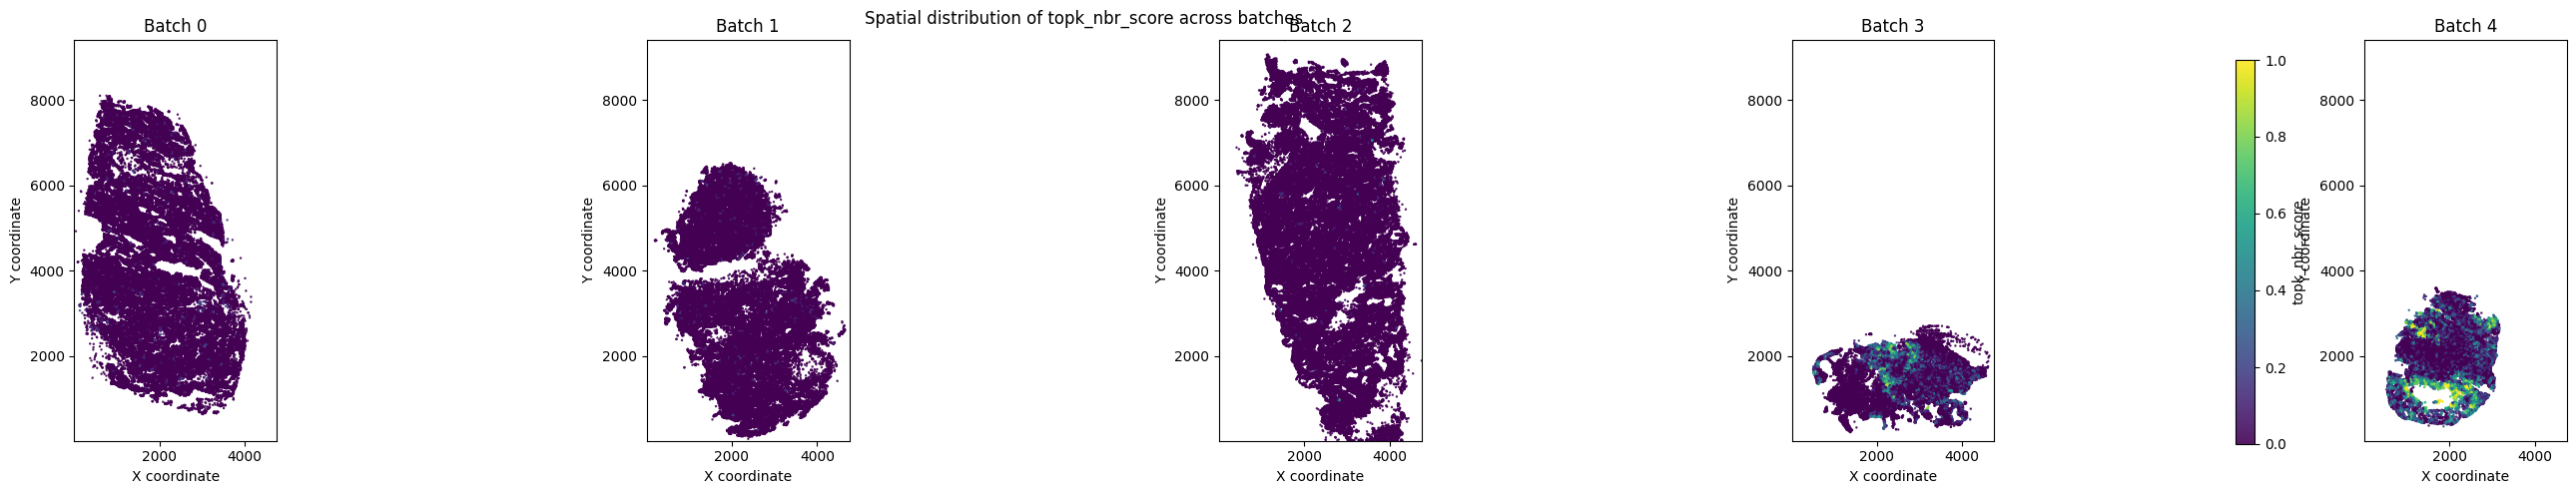

(<Figure size 3000x500 with 6 Axes>,
 array([[<Axes: title={'center': 'Batch 0'}, xlabel='X coordinate', ylabel='Y coordinate'>,
         <Axes: title={'center': 'Batch 1'}, xlabel='X coordinate', ylabel='Y coordinate'>,
         <Axes: title={'center': 'Batch 2'}, xlabel='X coordinate', ylabel='Y coordinate'>,
         <Axes: title={'center': 'Batch 3'}, xlabel='X coordinate', ylabel='Y coordinate'>,
         <Axes: title={'center': 'Batch 4'}, xlabel='X coordinate', ylabel='Y coordinate'>]],
       dtype=object))

In [94]:
plot_spatial_score_by_batch(
    adata=adata1,
    spatial_key="spatial",
    label_key="topk_nbr_score",
    batch_key="adata_batch_ids",
    title="Spatial distribution of topk_nbr_score across batches",
)

## Plotting tests

In [70]:
from typing import Optional

import anndata as ad

import seaborn as sns
import matplotlib.pyplot as plt


def plot_code_assignment_on_xy_coordinates(
        adata: ad.AnnData,
        spatial_key: str = "spatial",
        label_key: str = "Indices",
        save_fname: Optional[str] = None,
        title: Optional[str] = "X-Y coordinates colored by Code Indices",
    ) -> None:
    """
    Plots the X-Y coordinates of the cells colored by the code indices.

    Parameters
    ----------
    adata : ad.AnnData
        The AnnData object containing the data to plot.
    spatial_key : str, optional
        The key in adata.obsm to use for the spatial coordinates.
    label_key : str, optional
        The key in adata.obs to use for the label.
    save_fname : str, optional
        The file name to save the plot to.
    title : str, optional
        The title of the plot.

    Returns
    -------
    None
    """
    # plot the X-Y coordinates of the cells colored by the code indices
    fig, ax = plt.subplots(1,1, figsize=(4,3))
    
    sns.scatterplot(
        x=adata.obsm[spatial_key][:,0],
        y=adata.obsm[spatial_key][:,1],
        hue=adata.obs[label_key]
    )

    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])

    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()

    fig.legend(
            handles, labels,
            title=label_key,
            loc='center left',
            bbox_to_anchor=(0.95, 0.5),
            borderaxespad=0.1,
            frameon=False,
        )

    if save_fname:
        plt.savefig(
            save_fname,
            dpi=300,
            bbox_inches='tight',
        )
    else:
        plt.show()    

In [31]:
adata.obs['Indices'] = adata.uns['Indices'].tolist()

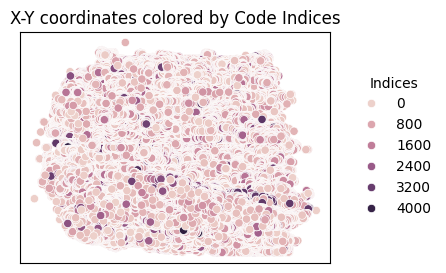

In [32]:
plot_code_assignment_on_xy_coordinates(adata)

In [63]:
adata.obs['clinical_risk'].value_counts()

clinical_risk
low     206864
high     53329
Name: count, dtype: int64

In [66]:
adata.obs['Indices'].value_counts()[:5]

Indices
709     9119
835     8699
307     8179
580     7919
1020    6735
Name: count, dtype: int64

## Functions (prettier?)

In [70]:
from typing import Optional
import h5py
import anndata as ad
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score


def read_h5ad(path: str, read_uns: bool = False) -> ad.AnnData:
    """
    Read selected components of an .h5ad file using h5py and return an AnnData object.

    Parameters
    ----------
    path : str
        Path to the .h5ad file.
    read_uns : bool, optional (default: False)
        Whether to load the 'uns' field (can be large).

    Returns
    -------
    AnnData
        The AnnData object containing obs, var, obsm, obsp, varm, varp, and optionally uns.
    """
    with h5py.File(path, "r") as f:
        adata = ad.AnnData(
            # Uncomment if you want the main matrix
            # X=ad._io.h5ad.read_elem(f['X']) if 'X' in f else None,
            obs=ad._io.h5ad.read_elem(f["obs"]) if "obs" in f else None,
            var=ad._io.h5ad.read_elem(f["var"]) if "var" in f else None,
            obsm=ad._io.h5ad.read_elem(f["obsm"]) if "obsm" in f else None,
            obsp=ad._io.h5ad.read_elem(f["obsp"]) if "obsp" in f else None,
            varm=ad._io.h5ad.read_elem(f["varm"]) if "varm" in f else None,
            varp=ad._io.h5ad.read_elem(f["varp"]) if "varp" in f else None,
            uns=ad._io.h5ad.read_elem(f["uns"]) if read_uns and "uns" in f else None,
        )
    return adata

import pickle
def open_from_pickle(sample_i):
    with open(sample_i,"rb") as handle:
        bar_m = pickle.load(handle)
    return bar_m


def test_clasification(adata_path, target_column, feature_key, test_size=0.20, max_depth=2, random_state=0, verbose=True):
    print("Reading adata...") if verbose
    if adata_path.endswith('h5ad'):
        adata = read_h5ad(adata_path)
    elif adata_path.endswith('pkl'):
        adata = open_from_pickle(adata_path)
    
    if feature_key not in adata.obsm_keys():
        raise KeyError(f"Feature key '{feature_key}' not found in adata.obsm.")

    if target_column not in adata.obs.columns:
        raise KeyError(f"Target column '{target_column}' not found in adata.obs.")
        
    print(f"Encoding target column '{target_column}' with one-hot encoding...") if verbose
    enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    y = enc.fit_transform(adata.obs[[target_column]])
    
    print(f"Using features from adata.obsm['{feature_key}']...") if verbose
    X = adata.obsm[feature_key]
    
    print("Splitting train and test...") if verbose
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    print("Training random forest classifier...") if verbose
    clf = RandomForestClassifier(max_depth=max_depth, random_state=random_state, n_jobs=-1)
    clf.fit(X_train, y_train)
    
    print("Predicting using classifier...") if verbose
    y_pred = clf.predict(X_test)
    
    score = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {score:.4f}")
    
    return score
    
def test_clasification_average(adata_path, target_column, feature_key, test_size=0.20, max_depth=2, n_seeds=3, verbose=False):
    
    test_seeds = range(0, n_seeds)
    
    scores = []
    for seed in test_seeds:
        print(f'random state: {i}')
        scores.append(test_clasification(adata_path, target_column, feature_key, random_state=seed))
        print(f'------')
    
    avg_score = np.mean(scores)
    print(f"AVERAGE SCORE: {avg_score}")
    return avg_score

SyntaxError: expected 'else' after 'if' expression (2234149387.py, line 51)